In [1]:
import pandas as pd
import sys
import os

sys.path.append("./data-preprocessing")
import prepare_file
sys.path.pop()

# load data set
clean_dataset_file = "../Clean_NPFC-Test_Database_V2.csv"

if not os.path.isfile(clean_dataset_file):
  prepare_file.generate_prepared_file(clean_dataset_file)
df = pd.read_csv(clean_dataset_file)

relevant_columns = [
    "Subject_ID",
    "Timestamp",
    "Test_Time",
    "Task_Num",
    "Task_Time",
    "Task_Type",
    "Frame",
    "Task_Frame",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Face_Detection",
    "resmasknet_anger_aligned",
    "resmasknet_disgust_aligned",
    "resmasknet_fear_aligned",
    "resmasknet_happiness_aligned",
    "resmasknet_sadness_aligned",
    "resmasknet_surprise_aligned",
    "resmasknet_neutral_aligned",
    "resmasknet_max_emotion_value",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "HeadBandOn",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

df = df[relevant_columns]

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 22105 entries, 0 to 22104
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Subject_ID                    22105 non-null  str    
 1   Timestamp                     22105 non-null  str    
 2   Test_Time                     22105 non-null  str    
 3   Task_Num                      22105 non-null  float64
 4   Task_Time                     22105 non-null  str    
 5   Task_Type                     22105 non-null  int64  
 6   Frame                         22105 non-null  int64  
 7   Task_Frame                    22105 non-null  int64  
 8   Selfreport_valence            22105 non-null  int64  
 9   Selfreport_arousal            22105 non-null  int64  
 10  Selfreport_focus              22105 non-null  int64  
 11  Face_Detection                22105 non-null  int64  
 12  resmasknet_anger_aligned      22105 non-null  float64
 13  resmasknet_d

# Feature selection

Selecting the best features (X).
Also creating the features for prediction (Y).


In [2]:
# Grab resmasknet_dominant_emotion if you also want the emotion
result_df_regression = df["resmasknet_max_emotion_value"]

# Select relevant features
feature_columns = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

feature_df = df[feature_columns]

# Output the results of the feature selection
feature_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22105 entries, 0 to 22104
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Selfreport_valence   22105 non-null  int64  
 1   Selfreport_arousal   22105 non-null  int64  
 2   Selfreport_focus     22105 non-null  int64  
 3   Temperature_aligned  21774 non-null  float64
 4   EDA_aligned          21792 non-null  float64
 5   BVP_aligned          21767 non-null  float64
 6   Delta_TP9            22105 non-null  float64
 7   Delta_AF7            22105 non-null  float64
 8   Delta_AF8            22105 non-null  float64
 9   Delta_TP10           22105 non-null  float64
 10  Theta_TP9            22105 non-null  float64
 11  Theta_AF7            22105 non-null  float64
 12  Theta_AF8            22105 non-null  float64
 13  Theta_TP10           22105 non-null  float64
 14  Alpha_TP9            22105 non-null  float64
 15  Alpha_AF7            22105 non-null  float64
 1

# Model Training

**CURRENTLY WHAT'S SHOWN IN THE OUTPUT IS BAD MODELS WITH VERY SMALL SIZE.**

- Ideally, uncomment the lines prefixed with _# BIG COMPUTE:_ to actually get the real model.
- This was done just to test the pipeline


In [3]:
# This is added because when testing with low iterations, some models throw convergence warnings. Annoying
# Remove when training real models
import warnings

warnings.filterwarnings("ignore")

In [4]:
### Data normalization preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# All physiological signals, brainwave bands, and temperature
sensor_and_eeg_features = [
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
]

# Subjective human ratings
survey_features = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Perceived_Tiredness",
    "Perceived_Stress",
]

# Metadata/Demographics left untouched
binary_features = ["Gender", "Wearing_Glasses"]

# Robust pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("robust_sensors", RobustScaler(), sensor_and_eeg_features),
        ("minmax_survey", MinMaxScaler(), survey_features),
        ("pass_binary", "passthrough", binary_features),
    ]
)

# HOW TO USE:
# X_train_scaled = preprocessor.fit_transform(X_train)
# X_test_scaled = preprocessor.transform(X_test)

## Regression models

Here we are tranining the regression models. That is, models that will predict the uncertainty of the resmasknet FER model.


In [5]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Convert all variables to float to ensure missing values are numpy safe (from pandas.NA to np.nan)
# and also filling any created NaN to avoid downstream scikit-learn estimator failures.
X = feature_df.astype(float).fillna(0)
y = result_df_regression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessor perfectly matching the comment block example
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Extract generated feature names dynamically
feature_names_out = preprocessor.get_feature_names_out()


In [6]:
# --- Random Forest Regressor with RFE Backward Elimination ---
print("--- Random Forest Regressor ---")
# BIG COMPUTE: 
rf_reg = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
# rf_reg = RandomForestRegressor(random_state=42, n_estimators=1, n_jobs=-1)
# RFECV performs recursive backward elimination and selected best features by CV score
rf_selector = RFECV(estimator=rf_reg, step=0.1, cv=3, scoring="neg_mean_squared_error")
rf_selector.fit(X_train_scaled, y_train)

X_train_rf = rf_selector.transform(X_train_scaled)
X_test_rf = rf_selector.transform(X_test_scaled)

rf_reg.fit(X_train_rf, y_train)
y_pred_rf = rf_reg.predict(X_test_rf)

print(f"Optimal number of features: {rf_selector.n_features_}")
print(f"Selected features: {feature_names_out[rf_selector.support_]}")

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
n_rf = X_test_rf.shape[0]  # type: ignore
p_rf = X_test_rf.shape[1]  # type: ignore
adj_r2_rf = (
    1 - (1 - r2_rf) * (n_rf - 1) / (n_rf - p_rf - 1)
    if (n_rf - p_rf - 1) > 0
    else float("nan")
)

print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R-squared: {r2_rf:.4f}")
print(f"Adjusted R-squared: {adj_r2_rf:.4f}\n")

--- Random Forest Regressor ---
Optimal number of features: 30
Selected features: ['robust_sensors__Temperature_aligned' 'robust_sensors__EDA_aligned'
 'robust_sensors__BVP_aligned' 'robust_sensors__Delta_TP9'
 'robust_sensors__Delta_AF7' 'robust_sensors__Delta_AF8'
 'robust_sensors__Delta_TP10' 'robust_sensors__Theta_TP9'
 'robust_sensors__Theta_AF7' 'robust_sensors__Theta_AF8'
 'robust_sensors__Theta_TP10' 'robust_sensors__Alpha_TP9'
 'robust_sensors__Alpha_AF7' 'robust_sensors__Alpha_AF8'
 'robust_sensors__Alpha_TP10' 'robust_sensors__Beta_TP9'
 'robust_sensors__Beta_AF7' 'robust_sensors__Beta_AF8'
 'robust_sensors__Beta_TP10' 'robust_sensors__Gamma_TP9'
 'robust_sensors__Gamma_AF7' 'robust_sensors__Gamma_AF8'
 'robust_sensors__Gamma_TP10' 'minmax_survey__Selfreport_valence'
 'minmax_survey__Selfreport_arousal' 'minmax_survey__Selfreport_focus'
 'minmax_survey__Perceived_Tiredness' 'minmax_survey__Perceived_Stress'
 'pass_binary__Gender' 'pass_binary__Wearing_Glasses']
MSE: 0.0159
R

In [7]:
# --- Neural Network Regressor with SFS Backward Elimination ---
print("--- Neural Network Regressor ---")
# BIG COMPUTE: 
nn_reg = MLPRegressor(random_state=42, max_iter=1000, hidden_layer_sizes=(64, 32))
# nn_reg = MLPRegressor(random_state=42, max_iter=10, hidden_layer_sizes=(2, 2))
# SequentialFeatureSelector allows backward elimination on models without feature_importances_
try:
    # Drops features that do not improve performance by >0.001
    nn_selector = SequentialFeatureSelector(
        nn_reg,
        n_features_to_select="auto",
        tol=0.001,
        direction="backward",
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    nn_selector.fit(X_train_scaled, y_train)
except TypeError:
    # Fallback to keep 70% of features best for the NN
    nn_selector = SequentialFeatureSelector(
        nn_reg,
        n_features_to_select=max(1, int(X_train_scaled.shape[1] * 0.7)),
        direction="backward",
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    nn_selector.fit(X_train_scaled, y_train)

X_train_nn = nn_selector.transform(X_train_scaled)
X_test_nn = nn_selector.transform(X_test_scaled)

nn_reg.fit(X_train_nn, y_train)
y_pred_nn = nn_reg.predict(X_test_nn)

print(f"Selected features count: {nn_selector.get_support().sum()}")
print(f"Selected features: {feature_names_out[nn_selector.get_support()]}")

mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)
n_nn = X_test_nn.shape[0]
p_nn = X_test_nn.shape[1]
adj_r2_nn = (
    1 - (1 - r2_nn) * (n_nn - 1) / (n_nn - p_nn - 1)
    if (n_nn - p_nn - 1) > 0
    else float("nan")
)

print(f"MSE: {mse_nn:.4f}")
print(f"RMSE: {rmse_nn:.4f}")
print(f"MAE: {mae_nn:.4f}")
print(f"R-squared: {r2_nn:.4f}")
print(f"Adjusted R-squared: {adj_r2_nn:.4f}\n")

--- Neural Network Regressor ---
Selected features count: 29
Selected features: ['robust_sensors__Temperature_aligned' 'robust_sensors__EDA_aligned'
 'robust_sensors__BVP_aligned' 'robust_sensors__Delta_TP9'
 'robust_sensors__Delta_AF8' 'robust_sensors__Delta_TP10'
 'robust_sensors__Theta_TP9' 'robust_sensors__Theta_AF7'
 'robust_sensors__Theta_AF8' 'robust_sensors__Theta_TP10'
 'robust_sensors__Alpha_TP9' 'robust_sensors__Alpha_AF7'
 'robust_sensors__Alpha_AF8' 'robust_sensors__Alpha_TP10'
 'robust_sensors__Beta_TP9' 'robust_sensors__Beta_AF7'
 'robust_sensors__Beta_AF8' 'robust_sensors__Beta_TP10'
 'robust_sensors__Gamma_TP9' 'robust_sensors__Gamma_AF7'
 'robust_sensors__Gamma_AF8' 'robust_sensors__Gamma_TP10'
 'minmax_survey__Selfreport_valence' 'minmax_survey__Selfreport_arousal'
 'minmax_survey__Selfreport_focus' 'minmax_survey__Perceived_Tiredness'
 'minmax_survey__Perceived_Stress' 'pass_binary__Gender'
 'pass_binary__Wearing_Glasses']
MSE: 0.0207
RMSE: 0.1438
MAE: 0.1176
R-squa

## Classification models

Here we are tranining the classification models. That is, models that will classify if the predition of the resmasknet model with high or low confidence based on the selected features.

The way we define "high or low confidence resmasknet prediction" is by using a treshold. If the resmasknet model predicts and emotion with over a fixed percentage of confidence or more, then it is a high confidence prediction; otherwise, it is a low confidence one.


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)

thresholds = [0.7, 0.8, 0.9]

for thresh in thresholds:
    print("=" * 70)
    print(f" CLASSIFICATION WITH CONFIDENCE THRESHOLD = {thresh}")
    print("=" * 70)

    y_class = (result_df_regression >= thresh).astype(int)

    # Check class distribution
    if len(np.unique(y_class)) < 2:
        print(
            f"Warning: Not enough class diversity for threshold {thresh}. Skipping...\n"
        )
        continue

    # Convert all variables to float to ensure missing values are numpy safe (from pandas.NA to np.nan)
    # and also filling any created NaN to avoid downstream scikit-learn estimator failures.
    X_clf = feature_df.astype(float).fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_clf, y_class, test_size=0.2, random_state=42
    )

    # Apply preprocessor perfectly matching the comment block example
    X_train_scaled = preprocessor.fit_transform(X_train)
    X_test_scaled = preprocessor.transform(X_test)

    # Extract generated feature names dynamically
    feature_names_out = preprocessor.get_feature_names_out()

    # --- Random Forest Classifier ---
    print("--- Random Forest Classifier ---")
    # BIG COMPUTE: 
    rf_clf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
    # rf_clf = RandomForestClassifier(random_state=42, n_estimators=1, n_jobs=-1)
    rf_selector = RFECV(estimator=rf_clf, step=0.1, cv=3, scoring="accuracy")
    rf_selector.fit(X_train_scaled, y_train)

    X_train_rf = rf_selector.transform(X_train_scaled)
    X_test_rf = rf_selector.transform(X_test_scaled)
    rf_clf.fit(X_train_rf, y_train)
    y_pred_rf = rf_clf.predict(X_test_rf)

    y_pred_proba_rf = rf_clf.predict_proba(X_test_rf)[:, 1]

    print(f"Optimal features: {rf_selector.n_features_}")
    print(f"Features kept: {feature_names_out[rf_selector.support_]}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
    print(f"Macro F1 Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
    try:
        roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
        print(f"ROC-AUC: {roc_auc_rf:.4f}")
    except ValueError:
        pass
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_rf, zero_division=0))
    print("-" * 30)

    # --- Neural Network Classifier ---
    print("--- Neural Network Classifier ---")
    # BIG COMPUTE: 
    nn_clf = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=(64, 32))
    # nn_clf = MLPClassifier(random_state=42, max_iter=10, hidden_layer_sizes=(2, 2))

    try:
        # Tries to remove variables if accuracy isn't hurt by > 0.001
        nn_selector = SequentialFeatureSelector(
            nn_clf,
            n_features_to_select="auto",
            tol=0.001,
            direction="backward",
            cv=3,
            scoring="accuracy",
            n_jobs=-1,
        )
        nn_selector.fit(X_train_scaled, y_train)
    except TypeError:
        # Fallback to keep 70% of features
        nn_selector = SequentialFeatureSelector(
            nn_clf,
            n_features_to_select=max(1, int(X_train_scaled.shape[1] * 0.7)),
            direction="backward",
            cv=3,
            scoring="accuracy",
            n_jobs=-1,
        )
        nn_selector.fit(X_train_scaled, y_train)

    X_train_nn = nn_selector.transform(X_train_scaled)
    X_test_nn = nn_selector.transform(X_test_scaled)

    nn_clf.fit(X_train_nn, y_train)
    y_pred_nn = nn_clf.predict(X_test_nn)

    y_pred_proba_nn = nn_clf.predict_proba(X_test_nn)[:, 1]

    print(f"Optimal features: {nn_selector.get_support().sum()}")
    print(f"Features kept: {feature_names_out[nn_selector.get_support()]}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
    print(f"Macro F1 Score: {f1_score(y_test, y_pred_nn, average='macro'):.4f}")
    try:
        roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)
        print(f"ROC-AUC: {roc_auc_nn:.4f}")
    except ValueError:
        pass
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_nn, zero_division=0))
    print("\n\n")

 CLASSIFICATION WITH CONFIDENCE THRESHOLD = 0.7
--- Random Forest Classifier ---
Optimal features: 30
Features kept: ['robust_sensors__Temperature_aligned' 'robust_sensors__EDA_aligned'
 'robust_sensors__BVP_aligned' 'robust_sensors__Delta_TP9'
 'robust_sensors__Delta_AF7' 'robust_sensors__Delta_AF8'
 'robust_sensors__Delta_TP10' 'robust_sensors__Theta_TP9'
 'robust_sensors__Theta_AF7' 'robust_sensors__Theta_AF8'
 'robust_sensors__Theta_TP10' 'robust_sensors__Alpha_TP9'
 'robust_sensors__Alpha_AF7' 'robust_sensors__Alpha_AF8'
 'robust_sensors__Alpha_TP10' 'robust_sensors__Beta_TP9'
 'robust_sensors__Beta_AF7' 'robust_sensors__Beta_AF8'
 'robust_sensors__Beta_TP10' 'robust_sensors__Gamma_TP9'
 'robust_sensors__Gamma_AF7' 'robust_sensors__Gamma_AF8'
 'robust_sensors__Gamma_TP10' 'minmax_survey__Selfreport_valence'
 'minmax_survey__Selfreport_arousal' 'minmax_survey__Selfreport_focus'
 'minmax_survey__Perceived_Tiredness' 'minmax_survey__Perceived_Stress'
 'pass_binary__Gender' 'pass_bina

## WE ARE MISSING FEATURE IMPORTANCES TO KNOW WHAT FEATURES MATTER

Check this out. https://gemini.google.com/share/29bd58ad9a0e


macro avg => macro average F1

weighted avg => Weighted average F1

support => number of samples


In [9]:
# Random forest importances

selected_feature_names = feature_names_out[rf_selector.support_]

rf_importances = rf_reg.feature_importances_
rf_importance_df = pd.DataFrame({
  'Feature': selected_feature_names,
  'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print(rf_importance_df)

                                Feature  Importance
1           robust_sensors__EDA_aligned    0.105566
0   robust_sensors__Temperature_aligned    0.103390
21            robust_sensors__Gamma_AF8    0.065967
2           robust_sensors__BVP_aligned    0.045748
19            robust_sensors__Gamma_TP9    0.039883
26   minmax_survey__Perceived_Tiredness    0.036941
16             robust_sensors__Beta_AF7    0.036346
22           robust_sensors__Gamma_TP10    0.035846
11            robust_sensors__Alpha_TP9    0.032643
15             robust_sensors__Beta_TP9    0.032246
17             robust_sensors__Beta_AF8    0.032239
14           robust_sensors__Alpha_TP10    0.032064
18            robust_sensors__Beta_TP10    0.030949
3             robust_sensors__Delta_TP9    0.029402
7             robust_sensors__Theta_TP9    0.029199
4             robust_sensors__Delta_AF7    0.028345
6            robust_sensors__Delta_TP10    0.028219
10           robust_sensors__Theta_TP10    0.028075
20          

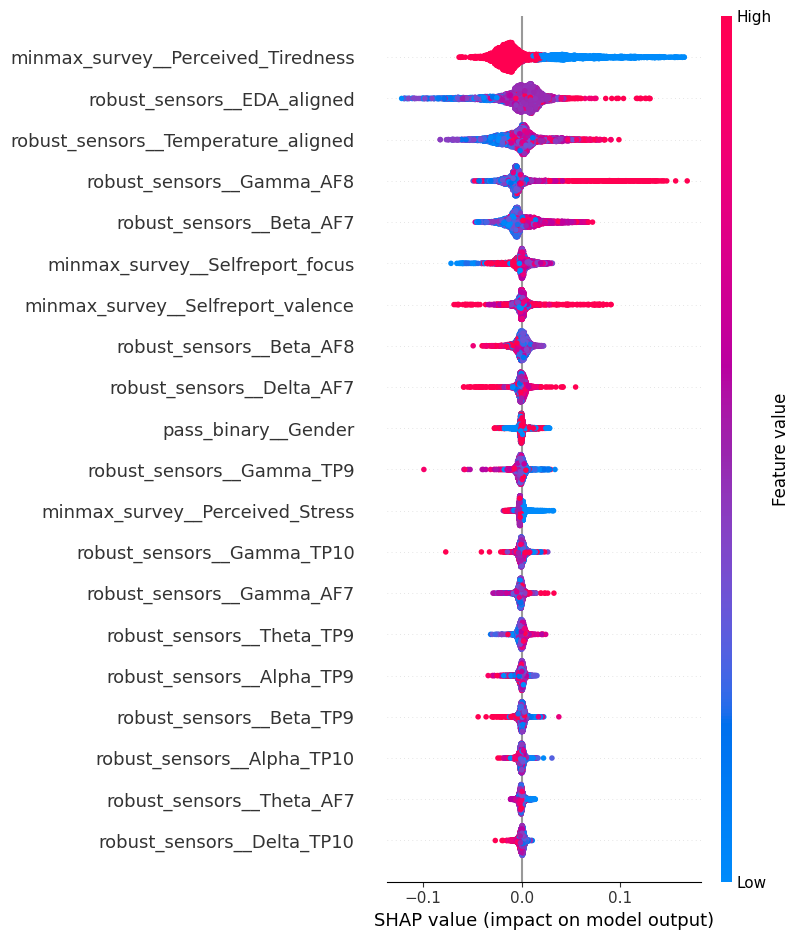

In [12]:
# SHAP (SHapley Additive exPlanations)
import shap

# 1. Summarize the background data so the explainer runs in seconds, not hours
background_data = shap.sample(X_train_rf, 50)

# 2. Create an explainer for the Random Forest model
# Note: We use X_train_rf because the model was trained on the reduced feature set
explainer = shap.TreeExplainer(rf_reg)

# 3. Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_rf)

# 4. Plot the summary
# We pass the selected feature names so the plot is readable
shap.summary_plot(shap_values, X_test_rf, feature_names=selected_feature_names)

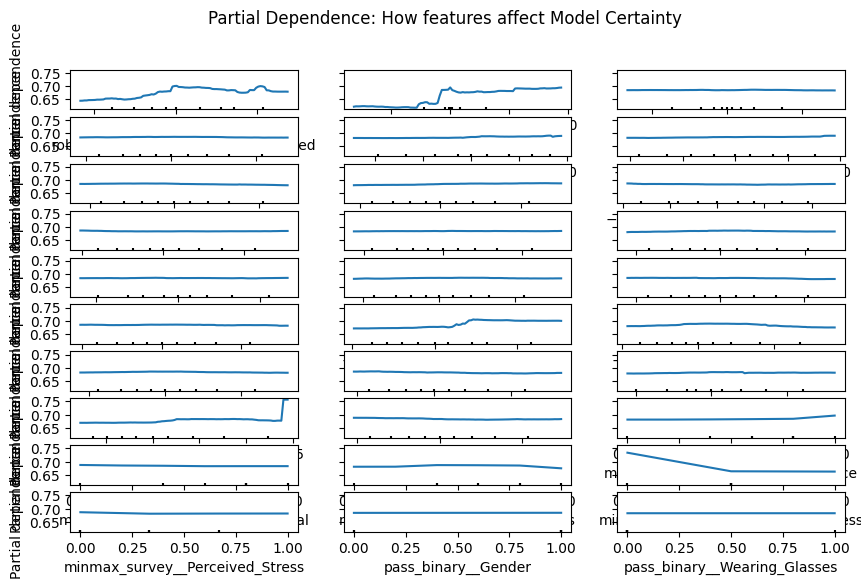

In [13]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Let's say SHAP told you feature index 0 and 2 are the most important
# (You can also pass feature names if your X_train_rf is a pandas DataFrame)
features_to_plot = selected_feature_names

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    estimator=rf_reg,
    X=X_train_rf, 
    features=features_to_plot,
    feature_names=selected_feature_names, # Maps indices to names
    ax=ax
)
plt.suptitle("Partial Dependence: How features affect Model Certainty")
plt.show()

## Feature importance extraction for neural network

In [17]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Force the model to retrain on the selected features 
# to overwrite the 29-feature version currently stuck in memory.
nn_reg.fit(X_train_nn, y_train)

# 1. Get the names of the features that survived the NN feature selection
selected_features_nn = feature_names_out[nn_selector.get_support()]

# 2. Run Permutation Importance on the test set
# Added n_jobs=-1 to use all CPU cores and speed this up!
perm_importance = permutation_importance(
    nn_reg, X_test_nn, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# 3. Put it in a readable DataFrame
nn_importance_df = pd.DataFrame({
    'Feature': selected_features_nn,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("--- Neural Network Feature Importance ---")
print(nn_importance_df)

--- Neural Network Feature Importance ---
                                Feature  Importance_Mean  Importance_Std
1           robust_sensors__EDA_aligned         0.245208        0.016352
23   minmax_survey__Perceived_Tiredness         0.203123        0.008801
14             robust_sensors__Beta_AF7         0.134001        0.006265
18            robust_sensors__Gamma_AF7         0.130959        0.010217
11            robust_sensors__Alpha_AF7         0.109155        0.011214
3             robust_sensors__Delta_AF7         0.082130        0.006784
4             robust_sensors__Delta_AF8         0.076108        0.006220
17            robust_sensors__Gamma_TP9         0.071646        0.006651
19            robust_sensors__Gamma_AF8         0.067869        0.009626
15             robust_sensors__Beta_AF8         0.067437        0.007196
0   robust_sensors__Temperature_aligned         0.061015        0.003569
24      minmax_survey__Perceived_Stress         0.057714        0.004673
7        

100%|██████████| 4421/4421 [02:06<00:00, 34.93it/s]


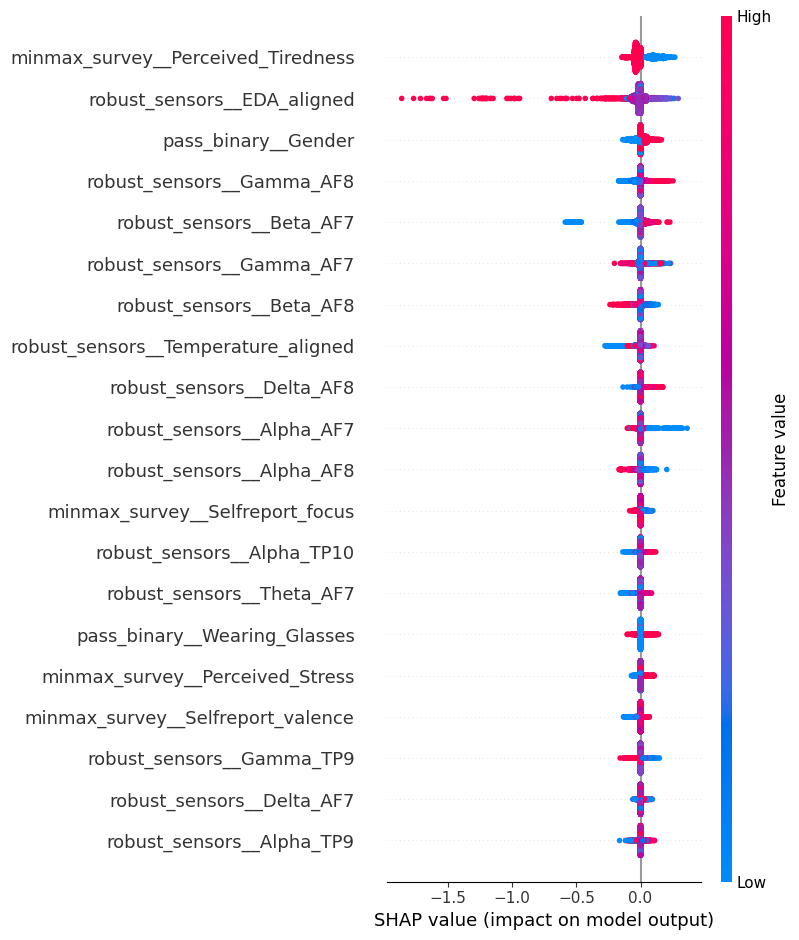

In [18]:
# 1. Summarize the background data so the explainer runs in seconds, not hours
# We take a representative sample of 50 points from the training data
background_data = shap.sample(X_train_nn, 50)

# 2. Create the explainer for the Neural Network using the background data
explainer_nn = shap.KernelExplainer(nn_reg.predict, background_data)

# 3. Calculate SHAP values for the test set (this might still take a minute)
shap_values_nn = explainer_nn.shap_values(X_test_nn)

# 4. Plot the summary
shap.summary_plot(
    shap_values_nn, 
    X_test_nn, 
    feature_names=selected_features_nn
)

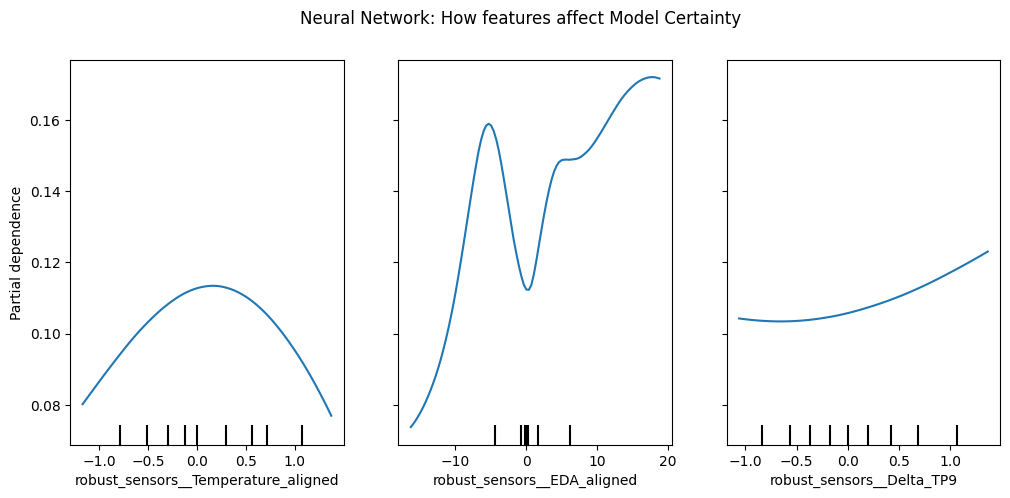

In [19]:
# Let's say you want to plot the top 3 features found in Step 1
features_to_plot_nn = [0, 1, 2] 

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    estimator=nn_reg,
    X=X_train_nn, 
    features=features_to_plot_nn,
    feature_names=selected_features_nn,
    ax=ax
)
plt.suptitle("Neural Network: How features affect Model Certainty")
plt.show()